In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
#from xgboost import XGBClassifier

In [37]:
data_path = "CSE-CIC-IDS2018/02-14-2018.csv"
#data_path = "CSE-CIC-IDS2018/02-15-2018.csv"
#data_path = "sampled_output/sampled_combined.csv"
dataset = pd.read_csv(data_path)

print("Shape:", dataset.shape)
display(dataset.head())
dataset.info()

Shape: (1048575, 80)


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1048575 non-null  int64  
 1   Protocol           1048575 non-null  int64  
 2   Timestamp          1048575 non-null  object 
 3   Flow Duration      1048575 non-null  int64  
 4   Tot Fwd Pkts       1048575 non-null  int64  
 5   Tot Bwd Pkts       1048575 non-null  int64  
 6   TotLen Fwd Pkts    1048575 non-null  int64  
 7   TotLen Bwd Pkts    1048575 non-null  int64  
 8   Fwd Pkt Len Max    1048575 non-null  int64  
 9   Fwd Pkt Len Min    1048575 non-null  int64  
 10  Fwd Pkt Len Mean   1048575 non-null  float64
 11  Fwd Pkt Len Std    1048575 non-null  float64
 12  Bwd Pkt Len Max    1048575 non-null  int64  
 13  Bwd Pkt Len Min    1048575 non-null  int64  
 14  Bwd Pkt Len Mean   1048575 non-null  float64
 15  Bwd Pkt Len Std    1048575 non-n

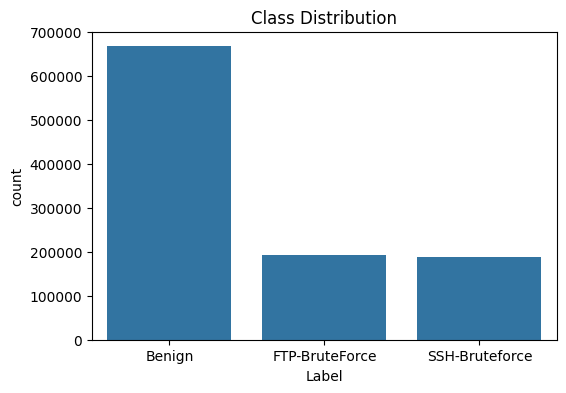

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(x=dataset['Label'])
plt.title("Class Distribution")
plt.show()

In [42]:
drop_cols = ['Dst Port', 
             'Protocol',
             'Timestamp',
             'Flow IAT Mean',
             'Flow IAT Std',
             'Flow IAT Max',
             'Flow IAT Min',
             'Fwd PSH Flags',
             'Bwd PSH Flags',
             'Fwd URG Flags',
             'Bwd URG Flags',
             'Fwd Header Len',
             'Bwd Header Len',
             'Fwd Pkts/s',
             'Bwd Pkts/s',
             'Pkt Len Var',
             'Down/Up Ratio',
             'Pkt Size Avg',
             'Fwd Seg Size Avg',
             'Bwd Seg Size Avg',
             'Fwd Byts/b Avg',
             'Fwd Pkts/b Avg',
             'Bwd Byts/b Avg',
             'Bwd Pkts/b Avg',
             'Fwd Act Data Pkts',
             'Fwd Seg Size Min',
             'Active Mean',
             'Active Std',
             'Active Max',
             'Active Min',
             'Idle Mean',
             'Idle Std',
             'Idle Max',
             'Idle Min',
             'Bwd Blk Rate Avg',
             'Fwd Blk Rate Avg']

reduced_dataset = dataset.drop(columns=drop_cols)

# replace infinity value as null value
reduced_dataset = reduced_dataset.replace(["Infinity", "infinity"], np.inf)
reduced_dataset = reduced_dataset.replace([np.inf, -np.inf], np.nan)
# drop all null values
reduced_dataset.dropna(inplace=True)

target = 'Label'
X = reduced_dataset.drop(columns=[target])
y = reduced_dataset[target]
print(X.columns)

Index(['Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts',
       'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min',
       'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max',
       'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s',
       'Flow Pkts/s', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Pkt Len Min',
       'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'FIN Flag Cnt',
       'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt',
       'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Subflow Fwd Pkts',
       'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts',
       'Init Fwd Win Byts', 'Init Bwd Win Byts'],
      dtype='object')


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Report:
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00    132762
FTP-BruteForce       1.00      1.00      1.00     38671
SSH-Bruteforce       1.00      1.00      1.00     37518

      accuracy                           1.00    208951
     macro avg       1.00      1.00      1.00    208951
  weighted avg       1.00      1.00      1.00    208951



In [41]:
model_path = "models/ids_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(dt, f)